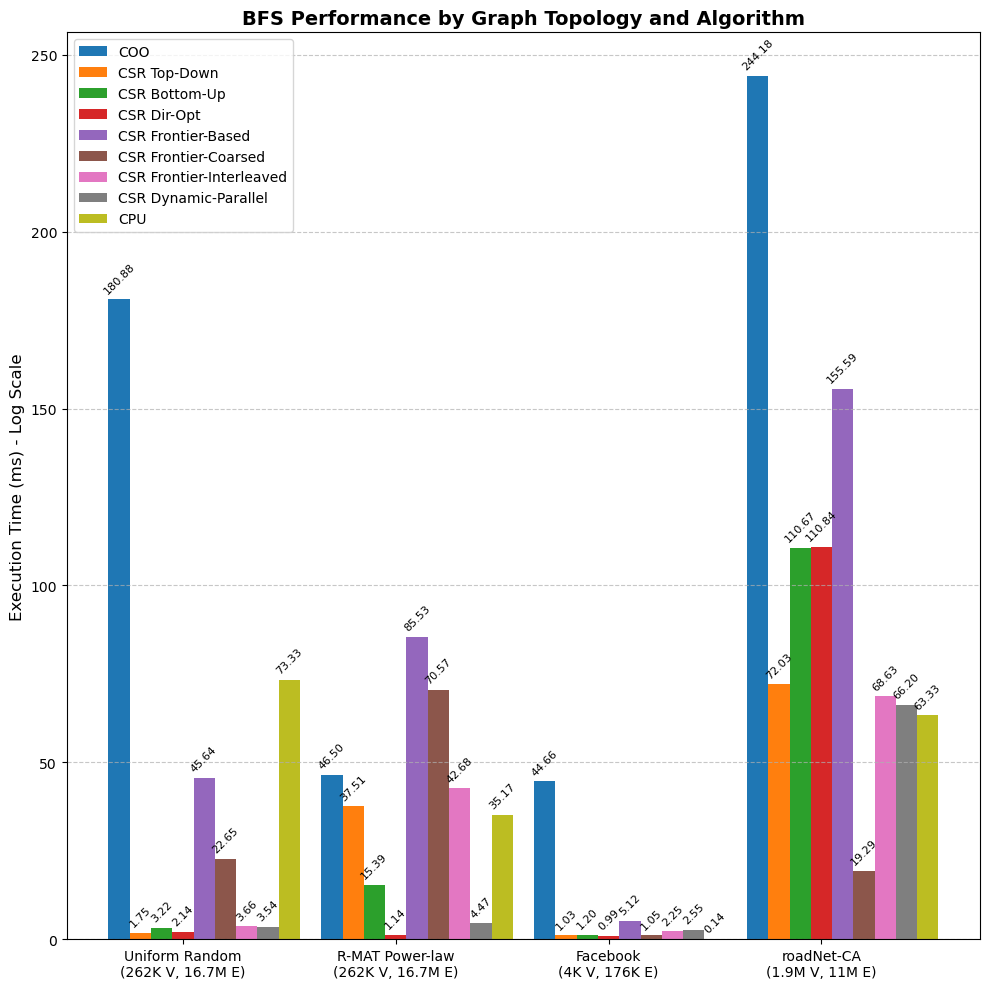

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import re

# 提取出的耗时数据 (ms)
graphs = ['Uniform Random\n(262K V, 16.7M E)', 'R-MAT Power-law\n(262K V, 16.7M E)', 
          'Facebook\n(4K V, 176K E)', 'roadNet-CA\n(1.9M V, 11M E)']

# cpu       = [96.351, 46.809,   0.295,  79.879]
# coo       = [4.234,   3.855,   2.260, 195.978]
# top_down  = [1.646,  39.488,   1.085,  79.758]
# bottom_up = [3.377,  17.379,   0.829, 128.260]
# dir_opt   = [2.214,   0.859,   0.767, 117.526]
TERMINAL_OUTPUT0 = """
--- Generating Uniform Random Graph ---
Graph built: Vertices = 262144, Total Directed Edges = 16777216
Selected BFS Source: 18882

Starting Benchmarks...
BFS (CPU): 85.970241 ms
BFS (COO) kernel: 4.145888 ms
BFS (CSR) kernel: 2.006944 ms using policy Top-Down
BFS (CSR) kernel: 3.028512 ms using policy Bottom-Up
BFS (CSR) kernel: 2.767968 ms using policy Direction-Optimized
BFS (CSR) kernel: 3.737632 ms using policy Frontier-Based
BFS (CSR) kernel: 23.170080 ms using policy Frontier-Coarsed
All policies matched correctly!
--- Generating R-MAT Power-law Graph ---
Graph built: Vertices = 262144, Total Directed Edges = 16777216
Selected BFS Source: 16804

Starting Benchmarks...
BFS (CPU): 50.139005 ms
BFS (COO) kernel: 3.708608 ms
BFS (CSR) kernel: 34.841698 ms using policy Top-Down
BFS (CSR) kernel: 16.411137 ms using policy Bottom-Up
BFS (CSR) kernel: 0.982400 ms using policy Direction-Optimized
BFS (CSR) kernel: 51.284641 ms using policy Frontier-Based
BFS (CSR) kernel: 74.313599 ms using policy Frontier-Coarsed
All policies matched correctly!
--- Loading Graph from File: ./data/facebook_combined.txt ---
Loaded 176468 directed edges (after making undirected) and 4039 vertices from ./data/facebook_combined.txt
Graph built: Vertices = 4039, Total Directed Edges = 176468
Selected BFS Source: 1849

Starting Benchmarks...
BFS (CPU): 0.244813 ms
BFS (COO) kernel: 2.535040 ms
BFS (CSR) kernel: 0.968000 ms using policy Top-Down
BFS (CSR) kernel: 0.878016 ms using policy Bottom-Up
BFS (CSR) kernel: 0.801408 ms using policy Direction-Optimized
BFS (CSR) kernel: 1.701984 ms using policy Frontier-Based
BFS (CSR) kernel: 0.973696 ms using policy Frontier-Coarsed
All policies matched correctly!
--- Loading Graph from File: ./data/roadNet-CA.txt ---
Loaded 11066428 directed edges (after making undirected) and 1971281 vertices from ./data/roadNet-CA.txt
Graph built: Vertices = 1971281, Total Directed Edges = 11066428
Selected BFS Source: 672485

Starting Benchmarks...
BFS (CPU): 88.017381 ms
BFS (COO) kernel: 191.259354 ms
BFS (CSR) kernel: 72.964897 ms using policy Top-Down
BFS (CSR) kernel: 103.619583 ms using policy Bottom-Up
BFS (CSR) kernel: 113.042015 ms using policy Direction-Optimized
BFS (CSR) kernel: 70.707268 ms using policy Frontier-Based
BFS (CSR) kernel: 19.240255 ms using policy Frontier-Coarsed
All policies matched correctly!
"""
TERMINAL_OUTPUT = """ArithmeticError--- Generating Uniform Random Graph ---
Graph built: Vertices = 262144, Total Directed Edges = 16777216
Selected BFS Source: 18882

Starting Benchmarks...
BFS (CPU): 73.334091 ms
BFS (COO) kernel: 180.875320 ms
BFS (CSR) kernel: 1.746752 ms using policy Top-Down
BFS (CSR) kernel: 3.223520 ms using policy Bottom-Up
BFS (CSR) kernel: 2.138592 ms using policy Direction-Optimized
BFS (CSR) kernel: 45.642399 ms using policy Frontier-Based
BFS (CSR) kernel: 22.648832 ms using policy Frontier-Coarsed
BFS (CSR) kernel: 3.663104 ms using policy Frontier-Interleaved
BFS (CSR) kernel: 3.541664 ms using policy Dynamic-Parallel
All policies matched correctly!
--- Generating R-MAT Power-law Graph ---
Graph built: Vertices = 262144, Total Directed Edges = 16777216
Selected BFS Source: 16804

Starting Benchmarks...
BFS (CPU): 35.173862 ms
BFS (COO) kernel: 46.499554 ms
BFS (CSR) kernel: 37.512066 ms using policy Top-Down
BFS (CSR) kernel: 15.387360 ms using policy Bottom-Up
BFS (CSR) kernel: 1.135520 ms using policy Direction-Optimized
BFS (CSR) kernel: 85.531036 ms using policy Frontier-Based
BFS (CSR) kernel: 70.569344 ms using policy Frontier-Coarsed
BFS (CSR) kernel: 42.678593 ms using policy Frontier-Interleaved
BFS (CSR) kernel: 4.468192 ms using policy Dynamic-Parallel
All policies matched correctly!
--- Loading Graph from File: ./data/facebook_combined.txt ---
Loaded 176468 directed edges (after making undirected) and 4039 vertices from ./data/facebook_combined.txt
Graph built: Vertices = 4039, Total Directed Edges = 176468
Selected BFS Source: 1849

Starting Benchmarks...
BFS (CPU): 0.140124 ms
BFS (COO) kernel: 44.659328 ms
BFS (CSR) kernel: 1.032896 ms using policy Top-Down
BFS (CSR) kernel: 1.197408 ms using policy Bottom-Up
BFS (CSR) kernel: 0.990656 ms using policy Direction-Optimized
BFS (CSR) kernel: 5.124800 ms using policy Frontier-Based
BFS (CSR) kernel: 1.045088 ms using policy Frontier-Coarsed
BFS (CSR) kernel: 2.253344 ms using policy Frontier-Interleaved
BFS (CSR) kernel: 2.552704 ms using policy Dynamic-Parallel
All policies matched correctly!
--- Loading Graph from File: ./data/roadNet-CA.txt ---
Loaded 11066428 directed edges (after making undirected) and 1971281 vertices from ./data/roadNet-CA.txt
Graph built: Vertices = 1971281, Total Directed Edges = 11066428
Selected BFS Source: 672485

Starting Benchmarks...
BFS (CPU): 63.325839 ms
BFS (COO) kernel: 244.179321 ms
BFS (CSR) kernel: 72.030754 ms using policy Top-Down
BFS (CSR) kernel: 110.668861 ms using policy Bottom-Up
BFS (CSR) kernel: 110.841057 ms using policy Direction-Optimized
BFS (CSR) kernel: 155.585663 ms using policy Frontier-Based
BFS (CSR) kernel: 19.285376 ms using policy Frontier-Coarsed
BFS (CSR) kernel: 68.632835 ms using policy Frontier-Interleaved
BFS (CSR) kernel: 66.199326 ms using policy Dynamic-Parallel
All policies matched correctly!
"""
# 使用正则表达式提取数据
cpu = re.findall(r'BFS \(CPU\): ([\d.]+) ms', TERMINAL_OUTPUT)
coo = re.findall(r'BFS \(COO\) kernel: ([\d.]+) ms', TERMINAL_OUTPUT)
top_down = re.findall(r'BFS \(CSR\) kernel: ([\d.]+) ms using policy Top-Down', TERMINAL_OUTPUT)
bottom_up = re.findall(r'BFS \(CSR\) kernel: ([\d.]+) ms using policy Bottom-Up', TERMINAL_OUTPUT)
dir_opt = re.findall(r'BFS \(CSR\) kernel: ([\d.]+) ms using policy Direction-Optimized', TERMINAL_OUTPUT)
frontier_based = re.findall(r'BFS \(CSR\) kernel: ([\d.]+) ms using policy Frontier-Based', TERMINAL_OUTPUT)
frontier_coarsed = re.findall(r'BFS \(CSR\) kernel: ([\d.]+) ms using policy Frontier-Coarsed', TERMINAL_OUTPUT)
frontier_interleaved = re.findall(r'BFS \(CSR\) kernel: ([\d.]+) ms using policy Frontier-Interleaved', TERMINAL_OUTPUT)
dynamic_parallel = re.findall(r'BFS \(CSR\) kernel: ([\d.]+) ms using policy Dynamic-Parallel', TERMINAL_OUTPUT)
assert len(cpu) == len(coo) == len(top_down) == len(bottom_up) == len(dir_opt) == len(frontier_based) == len(frontier_coarsed) == len(frontier_interleaved) == len(dynamic_parallel) == len(graphs)
for lst in [cpu, coo, top_down, bottom_up, dir_opt, frontier_based, frontier_coarsed, frontier_interleaved, dynamic_parallel]:
    for i in range(len(lst)):
        lst[i] = float(lst[i])

x = np.arange(len(graphs))
width = 0.1  # 柱子宽度

fig, ax = plt.subplots(figsize=(10, 10), dpi=100)

# 绘制分组柱状图
rects1 = ax.bar(x - 3*width, coo, width, label='COO')
rects2 = ax.bar(x - 2*width, top_down, width, label='CSR Top-Down')
rects3 = ax.bar(x - width, bottom_up, width, label='CSR Bottom-Up')
rects4 = ax.bar(x, dir_opt, width, label='CSR Dir-Opt')
rects5 = ax.bar(x + width, frontier_based, width, label='CSR Frontier-Based')
rects6 = ax.bar(x + 2*width, frontier_coarsed, width, label='CSR Frontier-Coarsed')
rects7 = ax.bar(x + 3*width, frontier_interleaved, width, label='CSR Frontier-Interleaved')
rects8 = ax.bar(x + 4*width, dynamic_parallel, width, label='CSR Dynamic-Parallel')
rects9 = ax.bar(x + 5*width, cpu, width, label='CPU')

# 设置图表属性
ax.set_ylabel('Execution Time (ms) - Log Scale', fontsize=12)
ax.set_title('BFS Performance by Graph Topology and Algorithm', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(graphs, fontsize=10)
ax.legend(fontsize=10)

# 设置Y轴为对数刻度，以便同时看清 0.7ms 和 195ms 的数据
# ax.set_yscale('log')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 在柱子上标注具体数值
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 垂直偏移3个点
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, rotation=45)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)
autolabel(rects5)
autolabel(rects6)
autolabel(rects7)
autolabel(rects8)
autolabel(rects9)
fig.tight_layout()
plt.savefig('data/bfs_benchmark.png')
plt.show()


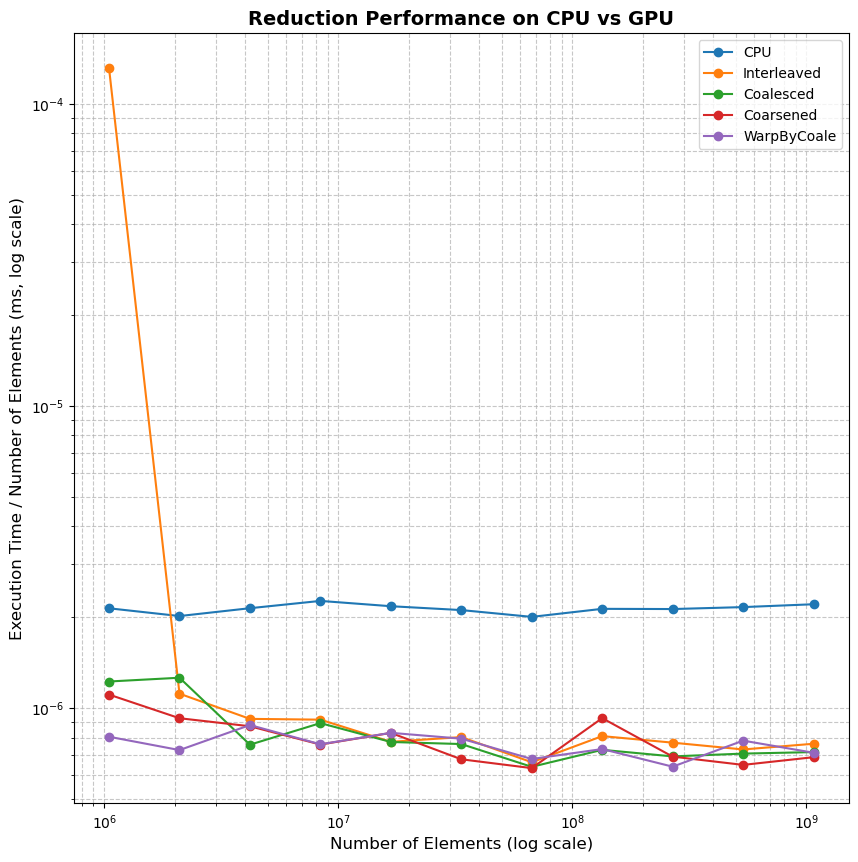

In [6]:
TERMINAL_OUTPUT_REDUCTION = """
================================================
Reducing 1048576 elements (4.00 MB)
CPU             Time:    2.247 ms | Result: 511.997467
GPU Interleaved Time:  138.003 ms | Kernel Time:  146.115 ms | Result: 511.997467
GPU Coalesced   Time:    1.286 ms | Kernel Time:    0.115 ms | Result: 511.997467
GPU Coarsened   Time:    1.164 ms | Kernel Time:    0.087 ms | Result: 511.997467
GPU WarpByCoale Time:    0.844 ms | Kernel Time:    0.045 ms | Result: 511.997467

================================================
Reducing 2097152 elements (8.00 MB)
CPU             Time:    4.236 ms | Result: 724.052734
GPU Interleaved Time:    2.344 ms | Kernel Time:    0.133 ms | Result: 724.052734
GPU Coalesced   Time:    2.647 ms | Kernel Time:    0.278 ms | Result: 724.052734
GPU Coarsened   Time:    1.944 ms | Kernel Time:    0.049 ms | Result: 724.052734
GPU WarpByCoale Time:    1.525 ms | Kernel Time:    0.056 ms | Result: 724.052734

================================================
Reducing 4194304 elements (16.00 MB)
CPU             Time:    8.994 ms | Result: 1024.093140
GPU Interleaved Time:    3.869 ms | Kernel Time:    0.183 ms | Result: 1024.093140
GPU Coalesced   Time:    3.178 ms | Kernel Time:    0.103 ms | Result: 1024.093140
GPU Coarsened   Time:    3.657 ms | Kernel Time:    0.061 ms | Result: 1024.093140
GPU WarpByCoale Time:    3.691 ms | Kernel Time:    0.072 ms | Result: 1024.093140

================================================
Reducing 8388608 elements (32.00 MB)
CPU             Time:   19.017 ms | Result: 1448.173828
GPU Interleaved Time:    7.692 ms | Kernel Time:    0.427 ms | Result: 1448.173828
GPU Coalesced   Time:    7.492 ms | Kernel Time:    0.312 ms | Result: 1448.173828
GPU Coarsened   Time:    6.363 ms | Kernel Time:    0.200 ms | Result: 1448.173828
GPU WarpByCoale Time:    6.375 ms | Kernel Time:    0.136 ms | Result: 1448.173828

================================================
Reducing 16777216 elements (64.00 MB)
CPU             Time:   36.527 ms | Result: 2047.851685
GPU Interleaved Time:   12.991 ms | Kernel Time:    0.479 ms | Result: 2047.851685
GPU Coalesced   Time:   12.976 ms | Kernel Time:    0.341 ms | Result: 2047.851685
GPU Coarsened   Time:   13.906 ms | Kernel Time:    0.372 ms | Result: 2047.851685
GPU WarpByCoale Time:   13.914 ms | Kernel Time:    0.333 ms | Result: 2047.851685

================================================
Reducing 33554432 elements (128.00 MB)
CPU             Time:   70.931 ms | Result: 2896.634033
GPU Interleaved Time:   26.941 ms | Kernel Time:    0.853 ms | Result: 2896.634033
GPU Coalesced   Time:   25.547 ms | Kernel Time:    0.720 ms | Result: 2896.634033
GPU Coarsened   Time:   22.745 ms | Kernel Time:    0.527 ms | Result: 2896.634033
GPU WarpByCoale Time:   26.618 ms | Kernel Time:    0.551 ms | Result: 2896.634033

================================================
Reducing 67108864 elements (256.00 MB)
CPU             Time:  134.703 ms | Result: 4096.066406
GPU Interleaved Time:   44.470 ms | Kernel Time:    1.622 ms | Result: 4096.066406
GPU Coalesced   Time:   42.949 ms | Kernel Time:    1.308 ms | Result: 4096.066406
GPU Coarsened   Time:   42.527 ms | Kernel Time:    0.911 ms | Result: 4096.066406
GPU WarpByCoale Time:   45.591 ms | Kernel Time:    1.191 ms | Result: 4096.066406

================================================
Reducing 134217728 elements (512.00 MB)
CPU             Time:  286.424 ms | Result: 5792.265625
GPU Interleaved Time:  108.551 ms | Kernel Time:    3.356 ms | Result: 5792.265625
GPU Coalesced   Time:   97.782 ms | Kernel Time:    2.772 ms | Result: 5792.265625
GPU Coarsened   Time:  124.492 ms | Kernel Time:    1.848 ms | Result: 5792.265625
GPU WarpByCoale Time:   98.360 ms | Kernel Time:    1.932 ms | Result: 5792.265625

================================================
Reducing 268435456 elements (1024.00 MB)
CPU             Time:  571.959 ms | Result: 8192.588867
GPU Interleaved Time:  206.549 ms | Kernel Time:   11.212 ms | Result: 8192.588867
GPU Coalesced   Time:  186.006 ms | Kernel Time:    5.766 ms | Result: 8192.588867
GPU Coarsened   Time:  185.682 ms | Kernel Time:    3.246 ms | Result: 8192.588867
GPU WarpByCoale Time:  171.991 ms | Kernel Time:    3.757 ms | Result: 8192.588867

================================================
Reducing 536870912 elements (2048.00 MB)
CPU             Time: 1160.997 ms | Result: 11585.324219
GPU Interleaved Time:  392.211 ms | Kernel Time:   12.733 ms | Result: 11585.324219
GPU Coalesced   Time:  380.028 ms | Kernel Time:   10.137 ms | Result: 11585.324219
GPU Coarsened   Time:  348.717 ms | Kernel Time:    6.361 ms | Result: 11585.324219
GPU WarpByCoale Time:  419.520 ms | Kernel Time:    7.415 ms | Result: 11585.324219

================================================
Reducing 1073741824 elements (4096.00 MB)
CPU             Time: 2373.190 ms | Result: 16383.630859
GPU Interleaved Time:  819.269 ms | Kernel Time:   25.900 ms | Result: 16383.630859
GPU Coalesced   Time:  768.957 ms | Kernel Time:   20.269 ms | Result: 16383.630859
GPU Coarsened   Time:  739.587 ms | Kernel Time:   12.585 ms | Result: 16383.630859
GPU WarpByCoale Time:  765.120 ms | Kernel Time:   14.860 ms | Result: 16383.630859
"""
import matplotlib.pyplot as plt
import numpy as np
import re

Ns = []
times = {'CPU': [], 'Interleaved': [], 'Coalesced': [], 'Coarsened': [], 'WarpByCoale': []}
for block in TERMINAL_OUTPUT_REDUCTION.strip().split('================================================'):
    if block.strip():
        N = re.search(r'Reducing (\d+) elements', block).group(1)
        Ns.append(int(N))
        times['CPU'].append(float(re.search(r'CPU\s+Time: +([\d.]+) ms', block).group(1)))
        times['Interleaved'].append(float(re.search(r'GPU Interleaved\s+Time: +([\d.]+) ms', block).group(1)))
        times['Coalesced'].append(float(re.search(r'GPU Coalesced\s+Time: +([\d.]+) ms', block).group(1)))
        times['Coarsened'].append(float(re.search(r'GPU Coarsened\s+Time: +([\d.]+) ms', block).group(1)))
        times['WarpByCoale'].append(float(re.search(r'GPU WarpByCoale\s+Time: +([\d.]+) ms', block).group(1)))
plt.figure(figsize=(10, 10), dpi=100)
Ns = np.array(Ns)
Ts = {key: np.array(times[key]) for key in times}
for key in times:
    plt.plot(Ns, Ts[key] / Ns, marker='o', label=key)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Elements (log scale)', fontsize=12)
plt.ylabel('Execution Time / Number of Elements (ms, log scale)', fontsize=12)
plt.title('Reduction Performance on CPU vs GPU', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, which="both", ls="--", alpha=0.7)
plt.savefig('data/reduction_benchmark.png')
plt.show()